<a href="https://colab.research.google.com/github/missbhati/ZnO-Adsorption-ML/blob/main/Adsorption_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.listdir()

['.config',
 'raw_data.csv - Sheet1 (2).csv',
 'parity_plot_full.png',
 'feature_importance.png',
 'raw_data.csv - Sheet1 (1).csv',
 'parity_plot_test.png',
 'parity_plot.png',
 'raw_data.csv - Sheet1.csv',
 'sample_data']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df.columns

Index(['Surface', 'Surface energy (ev/A2)', 'BL of Zn-O ', 'Efermi (eV)',
       'Molecule', 'H-L gap', 'polarity', 'Ads Mode', 'Eads (eV)'],
      dtype='object')

In [ ]:
TARGET = "Eads (eV)"

X = df.drop(TARGET, axis=1)
y = df[TARGET]

X.head()

,Surface,Surface energy (ev/A2),BL of Zn-O,Efermi (eV),Molecule,H-L gap,polarity,Ads Mode
0,1010,0.12,1.77,-2.99,CO2,-8.9442,0.000,3
1,1010,0.12,1.77,-2.99,CO,-6.8965,0.112,1
2,1010,0.12,1.77,-2.99,CH4,-8.9442,0.000,0
3,1010,0.12,1.77,-2.99,NO,-3.8521,0.159,2
4,1010,0.12,1.77,-2.99,NO2,-2.4273,0.320,1


In [ ]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Surface,Surface energy (ev/A2),BL of Zn-O,Efermi (eV),H-L gap,polarity,Ads Mode,Molecule_CO,Molecule_CO2,Molecule_H2,Molecule_H2S,Molecule_NO,Molecule_NO2,Molecule_SO2
0,1010,0.12,1.77,-2.99,-8.9442,0.000,3,False,True,False,False,False,False,False
1,1010,0.12,1.77,-2.99,-6.8965,0.112,1,True,False,False,False,False,False,False
2,1010,0.12,1.77,-2.99,-8.9442,0.000,0,False,False,False,False,False,False,False
3,1010,0.12,1.77,-2.99,-3.8521,0.159,2,False,False,False,False,True,False,False
4,1010,0.12,1.77,-2.99,-2.4273,0.320,1,False,False,False,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (32, 14)
Test size: (8, 14)


In [ ]:
import numpy as np

print("NaN in X:", np.isnan(X).sum().sum())
print("NaN in y:", np.isnan(y).sum())

NaN in X: 0
NaN in y: 0


In [ ]:
for col in X.columns:
    X[col] = X[col].fillna(X[col].mean())

In [ ]:
print("NaN in X:", X.isnull().sum().sum())

NaN in X: 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 1.4749749999999988
R2: 0.6922239387105205


In [ ]:
import os

os.makedirs("Images", exist_ok=True)

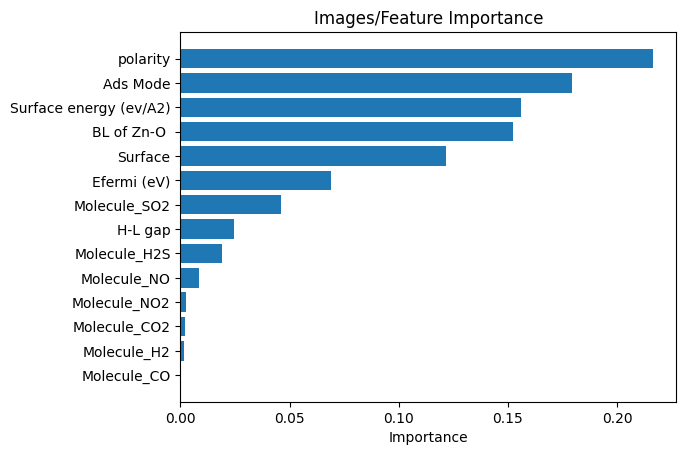

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.xlabel("Importance")
plt.title("Images/Feature Importance")

plt.show()

In [ ]:
model = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create model
model = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)

# Train model
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=300, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 1.531527396276791
R2: 0.6721539492423572


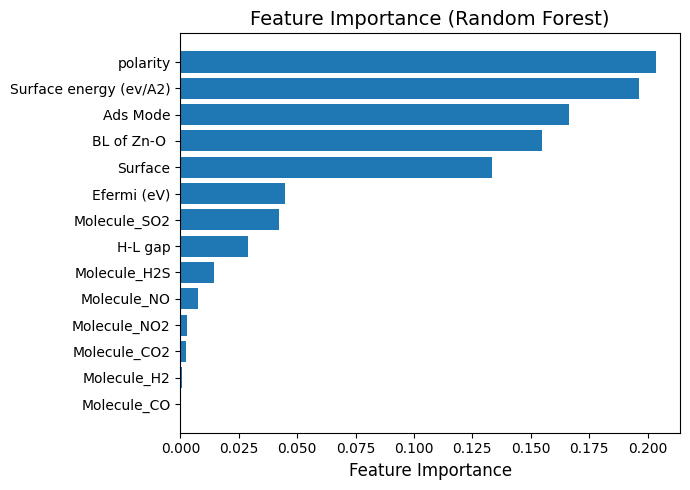

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

# Sort features
indices = np.argsort(importances)

plt.figure(figsize=(7,5))
plt.barh(range(len(indices)), importances[indices])

plt.yticks(range(len(indices)), features[indices], fontsize=10)
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Feature Importance (Random Forest)", fontsize=14)

plt.tight_layout()
plt.savefig("Images/feature_importance_1.png", dpi=300)

plt.show()

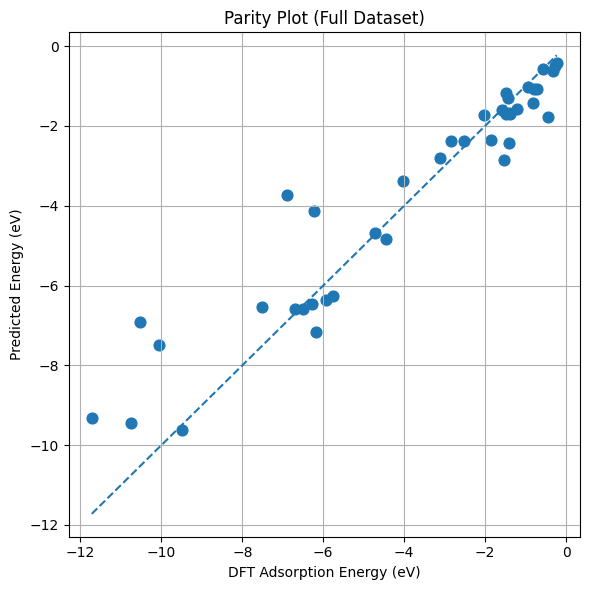

In [ ]:
# Predict on full dataset
y_full_pred = model.predict(X)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y, y_full_pred, s=60)

# Diagonal line
min_val = min(y.min(), y_full_pred.min())
max_val = max(y.max(), y_full_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("DFT Adsorption Energy (eV)")
plt.ylabel("Predicted Energy (eV)")
plt.title("Parity Plot (Full Dataset)")

plt.grid(True)
plt.tight_layout()

plt.savefig("Images/parity_plot_full.png", dpi=300)

plt.show()

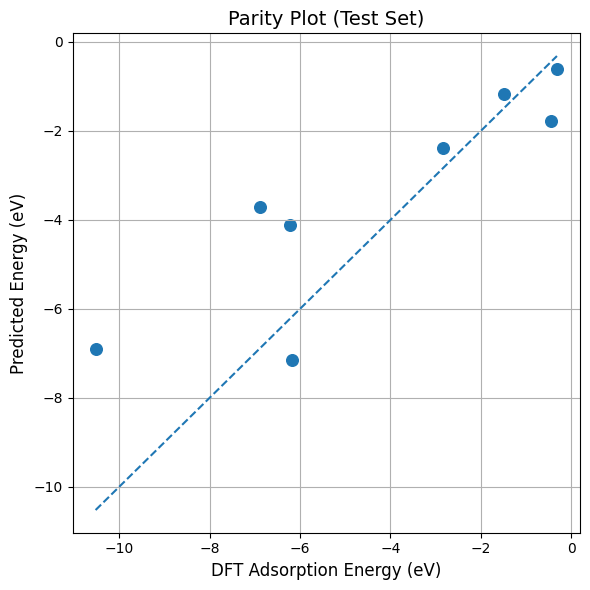

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# Scatter: test data only
plt.scatter(y_test, y_pred, s=70)

# Diagonal (perfect prediction line)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

# Labels
plt.xlabel("DFT Adsorption Energy (eV)", fontsize=12)
plt.ylabel("Predicted Energy (eV)", fontsize=12)
plt.title("Parity Plot (Test Set)", fontsize=14)

# Grid + layout
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig("Images/parity_plot_test.png", dpi=300)

plt.show()

In [ ]:
from google.colab import files
import os

for file in os.listdir("Images"):
    files.download("Images/" + file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -r Images.zip Images

  adding: Images/ (stored 0%)
  adding: Images/parity_plot_full.png (deflated 17%)
  adding: Images/parity_plot_test.png (deflated 15%)
  adding: Images/feature_importance_1.png (deflated 24%)


In [ ]:
from google.colab import files
files.download("Images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>